# Week 3: Topic Modeling & Entity Extraction

This notebook covers the complete Week 3 tasks:
1. **Topic Modeling (First Half)**: Ingesting datasets, training an LDA model, mapping topics to business labels, and plotting distribution by severity ratings.
2. **Named Entity Recognition (Second Half)**: Running spaCy NER on review texts to extract key entities, exporting the final dataset, and analyzing topic distribution by sentiment.

## Part 1: Topic Modeling (LDA)

### 1.1 Imports and Config

In [1]:
import os
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.corpora import Dictionary
from gensim.models import LdaModel

# Set relative paths from notebooks/ directory
labeled_data_path = '../outputs/labeled_dataset.csv'
cleaned_data_path = '../data/processed/reviews_cleaned.csv'
lda_model_dir = '../models/lda_model'
stage1_output_path = '../outputs/topics_stage1.csv'
fig_output_path = '../outputs/figures/topic_frequency.png'

print('Setup complete.')

Setup complete.


### 1.2 Ingest and Align Datasets

Load both `labeled_dataset.csv` and `reviews_cleaned.csv` and merge them on the review text column to bring back the preprocessed tokens **and** the enrichment metadata columns: `product_category`, `customer_type`, `customer_region`, `plant_location`, `feedback_date`, `resolution_status`.


In [2]:
df_label = pd.read_csv(labeled_data_path)
df_clean = pd.read_csv(cleaned_data_path)

# Inner join — bring tokens + enrichment columns from reviews_cleaned
ENRICH_COLS = [
    'feedback_text', 'tokens', 'feedback_topic',
    'product_category', 'customer_type', 'customer_region',
    'plant_location', 'feedback_date', 'resolution_status'
]
df_merged = pd.merge(
    df_label,
    df_clean[ENRICH_COLS],
    left_on='review text',
    right_on='feedback_text',
    how='inner'
)

print(f'Original Labeled rows: {len(df_label)}')
print(f'Merged rows with enrichment: {len(df_merged)}')
print(f'New columns added: product_category, customer_type, customer_region, plant_location, feedback_date, resolution_status')
df_merged[['review text', 'product_category', 'customer_type', 'customer_region', 'plant_location']].head(2)


Original Labeled rows: 2500
Merged rows with enrichment: 2500
New columns added: product_category, customer_type, customer_region, plant_location, feedback_date, resolution_status


,review text,product_category,customer_type,customer_region,plant_location
0,Our West India heavy machinery fabricator oper...,Billets and Blooms (Semi-Finished),Heavy Machinery Maker,West India,Raigarh (Chhattisgarh)
1,Received 153 MT of Beams and Columns (PF Secti...,Beams and Columns (PF Sections),Construction Company,South India,Angul (Odisha)


### 1.3 Format Tokens

Parse the string-serialized token lists back to list of strings using `ast.literal_eval`.

In [3]:
df_merged['tokens_list'] = df_merged['tokens'].apply(ast.literal_eval)
print('First row tokens list sample:', df_merged['tokens_list'].iloc[0][:5])
print('Token lists count:', len(df_merged['tokens_list']))

First row tokens list sample: ['west', 'india', 'heavy', 'machinery', 'fabricator']
Token lists count: 2500


### 1.4 Create Document-Term Matrix

Build a Gensim dictionary and filter extreme values to omit rare and overly common tokens.

In [4]:
dictionary = Dictionary(df_merged['tokens_list'])

# Filter terms occurring in < 5 documents or > 50% of the documents
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Generate Bag of Words (BoW) corpus
corpus = [dictionary.doc2bow(text) for text in df_merged['tokens_list']]

print(f'Unique dictionary tokens count: {len(dictionary)}')
print(f'BoW corpus sample (first doc): {corpus[0][:10]}')

Unique dictionary tokens count: 2205
BoW corpus sample (first doc): [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1)]


### 1.5 Train LDA Topic Model

Train an LDA model with `num_topics=6` for `passes=10` with seed `random_state=42`.

In [5]:
num_topics = 6
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10
)

print('LDA Model trained successfully.')

LDA Model trained successfully.


### 1.6 Print Top 20 Topic Words

Inspect the top 20 words for each topic to understand their semantic meanings.

In [6]:
for idx in range(num_topics):
    words = [w[0] for w in lda_model.show_topic(idx, topn=20)]
    print(f'Topic {idx}: {words}')

Topic 0: ['transit', 'packaging', 'bundle', 'surface', 'material', 'plant', 'advance', 'site', 'arrived', 'dispatch', 'infrastructure', 'without', 'condition', 'damage', 'strapping', 'intimation', 'hessian', 'coil', 'rail', 'jindal']
Topic 1: ['dispatch', 'plant', 'day', 'rail', 'delivery', 'steel', 'transit', 'railway', 'material', 'logistics', 'lot', 'south', 'order', 'operation', 'arrived', 'quality', 'raigarh', 'angul', 'stockist', 'received']
Topic 2: ['plate', 'coil', 'hr', 'quality', 'surface', 'material', 'consistency', 'fabrication', 'jindal', 'cement', 'operation', 'across', 'without', 'performance', 'supply', 'construction', 'north', 'product', 'characteristic', 'stamping']
Topic 3: ['rebars', 'panther', 'jindal', 'tmt', 'technical', 'construction', 'strength', 'material', 'plant', 'engineer', 'quality', 'service', 'infrastructure', 'office', 'regional', 'structural', 'sale', 'grade', 'specification', 'complaint']
Topic 4: ['term', 'commercial', 'freight', 'payment', 'invoic

### 1.7 Map Exact Labels to Topics

Map topics to the exact human-readable labels:
- **Topic 0 → "packaging and handling"**: transit, packaging, bundle, strapping, hessian, damage
- **Topic 1 → "delivery and logistics"**: dispatch, delivery, railway, transit, logistics, delay
- **Topic 2 → "product and quality"**: plate, coil, hr, quality, surface, consistency, cement
- **Topic 3 → "customer service"**: technical sales, engineer site visits, complaints, service
- **Topic 4 → "pricing and commercial"**: commercial terms, payment terms, invoices, credit, GST
- **Topic 5 → "technical compliance"**: dimensional tolerances, structural specifications, section profiles

In [7]:
topic_mapping = {
    0: 'packaging and handling',
    1: 'delivery and logistics',
    2: 'product and quality',
    3: 'customer service',
    4: 'pricing and commercial',
    5: 'technical compliance'
}

print('Topic mapping configured.')

Topic mapping configured.


### 1.8 Assign Dominant Topics

Extract dominant topic index for each review and map to the business label.

In [8]:
def get_dominant_topic_label(bow):
    probs = lda_model.get_document_topics(bow)
    dominant = max(probs, key=lambda x: x[1])[0]
    return topic_mapping[dominant]

df_merged['topic_label'] = [get_dominant_topic_label(b) for b in corpus]
df_merged['topic_label'].value_counts()

topic_label
technical compliance      629
customer service          524
packaging and handling    386
delivery and logistics    383
product and quality       326
pricing and commercial    252
Name: count, dtype: int64

### 1.9 Save Trained LDA Model & Dictionary

Save the LDA model and dictionary to `models/lda_model/` so it can be reloaded later.

In [9]:
os.makedirs(lda_model_dir, exist_ok=True)
lda_model.save(os.path.join(lda_model_dir, 'lda_model'))
dictionary.save(os.path.join(lda_model_dir, 'lda_dict'))

print(f'Model and Dictionary saved in {lda_model_dir}')

Model and Dictionary saved in ../models/lda_model


### 1.10 Save Intermediate Dataset

Save columns to `outputs/topics_stage1.csv`.

In [10]:
output_columns = [
    'review text',
    'rating',
    'vader_label',
    'distilbert_label',
    'distilbert_confidence',
    'topic_label'
]

df_merged[output_columns].to_csv(stage1_output_path, index=False)
print(f'Intermediate dataset saved to {stage1_output_path}')

Intermediate dataset saved to ../outputs/topics_stage1.csv


### 1.11 Generate and Save Topic Frequency Chart by Truth Severity Ratings

Plot the frequency bar chart segmented by the ratings-based ground-truth sentiment (`rating_based_truth`) and save it to `outputs/figures/topic_frequency.png`.

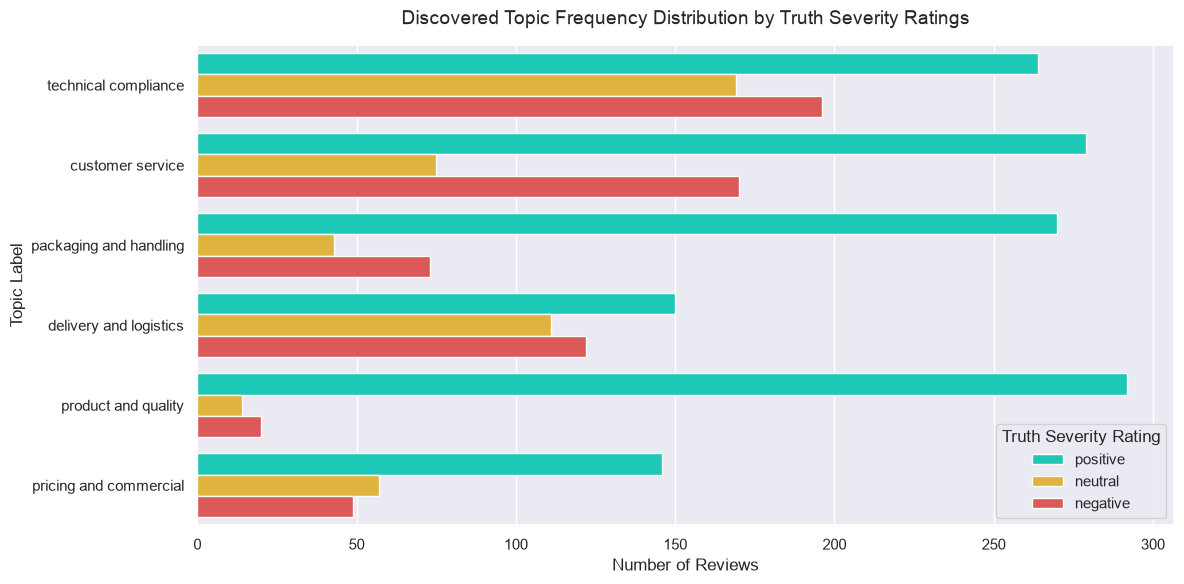

Topic frequency chart saved to ../outputs/figures/topic_frequency.png


In [11]:
plt.figure(figsize=(12, 6))
sns.set_theme(style='darkgrid')
order = df_merged['topic_label'].value_counts().index
ax = sns.countplot(
    data=df_merged,
    y='topic_label',
    hue='rating_based_truth',
    order=order,
    palette={'positive': '#00E5CC', 'neutral': '#FBBF24', 'negative': '#EF4444'}
)
plt.title('Discovered Topic Frequency Distribution by Truth Severity Ratings', fontsize=14, pad=15)
plt.xlabel('Number of Reviews', fontsize=12)
plt.ylabel('Topic Label', fontsize=12)
plt.legend(title='Truth Severity Rating', loc='lower right')
plt.tight_layout()

os.makedirs(os.path.dirname(fig_output_path), exist_ok=True)
plt.savefig(fig_output_path, dpi=150)
plt.show()

print(f'Topic frequency chart saved to {fig_output_path}')

## Part 2: Named Entity Recognition & Finalization

### 2.1 Load spaCy Model

Import spaCy and load the `en_core_web_sm` English language pipeline. Download it programmatically if it is not already available.

In [12]:
import spacy

# Load spacy model, downloading it if not present
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import subprocess
    import sys
    print('Downloading en_core_web_sm model...')
    subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)
    nlp = spacy.load('en_core_web_sm')

print('spaCy model loaded successfully.')

spaCy model loaded successfully.


### 2.2 Define and Apply Entity Extraction Function

Extract all named entities from each review text using the loaded spaCy model.

In [13]:
def extract_entities(text):
    if pd.isna(text):
        return []
    doc = nlp(str(text))
    return [ent.text for ent in doc.ents]

df_merged['entities'] = df_merged['review text'].apply(extract_entities)
print('Extracted entities count:', df_merged['entities'].apply(len).sum())
df_merged[['review text', 'entities']].head()

Extracted entities count: 12473


,review text,entities
0,Our West India heavy machinery fabricator oper...,"[West India, 361, Billets, Blooms, Raigarh, Ra..."
1,Received 153 MT of Beams and Columns (PF Secti...,"[153, Beams, Columns, Angul, South India, third]"
2,Our chassis fabrication unit in Central India ...,"[Central India, 319, Beams, Columns, Angul]"
3,Round Bars procured for our Central India infr...,"[Round Bars, Central India, 704, MT, Patratu]"
4,Our dealership operations benefit tremendously...,"[JSL, Beams, 199, MT, Raigarh, West India]"


### 2.3 Save Final Merged Dataset

Export the complete dataset with sentiment labels, dominant topics, and extracted entities to `outputs/extracted_topics.csv`.

In [14]:
final_output_path = '../outputs/extracted_topics.csv'
df_merged.to_csv(final_output_path, index=False)
print(f'Final merged dataset saved to {final_output_path}')

Final merged dataset saved to ../outputs/extracted_topics.csv


### 2.4 Analyze Topic Distribution by Model Sentiments

Generate a cross-tabulation table and plot the topic distribution against predicted sentiment categories.

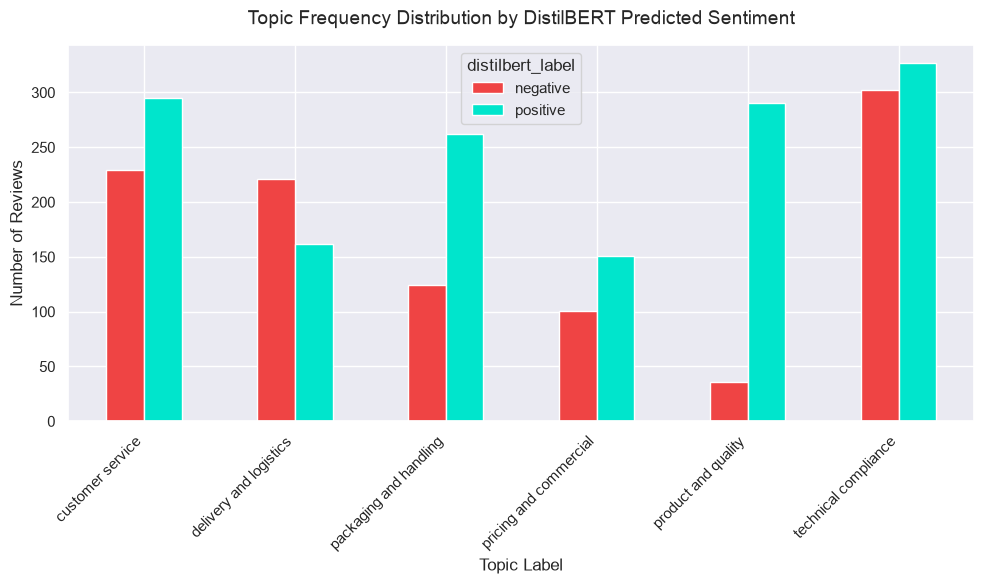

In [15]:
sentiment_topic = pd.crosstab(
    df_merged['topic_label'],
    df_merged['distilbert_label']
)

plt.figure(figsize=(10, 6))
sentiment_topic.plot(
    kind='bar',
    ax=plt.gca(),
    color=['#EF4444', '#00E5CC']
)
plt.title('Topic Frequency Distribution by DistilBERT Predicted Sentiment', fontsize=14, pad=15)
plt.xlabel('Topic Label', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/topic_sentiment_distribution.png', dpi=150)
plt.show()

## Part 3: Topic-Level Analysis & Cross-Tabulations

This section builds on the LDA topic assignments to surface actionable business insights: how sentiment distributes within each topic, which topics carry the most severe complaints, and how topics vary by customer region and product category.

### 3.1 Merge with Cleaned Data for Region & Product Attributes

Merge `topics_stage1.csv` with `reviews_cleaned.csv` on the feedback text to attach `customer_region` and `product_category` columns needed for cross-tabulations.

In [16]:
df_stage1 = pd.read_csv('../outputs/topics_stage1.csv')
df_raw    = pd.read_csv('../data/processed/reviews_cleaned.csv')

# Merge on the feedback text to get region and product_category
df_analysis = pd.merge(
    df_stage1,
    df_raw[['feedback_text', 'customer_region', 'product_category']],
    left_on='review text',
    right_on='feedback_text',
    how='inner'
).drop(columns=['feedback_text'])

print(f'Merged dataset shape: {df_analysis.shape}')
print(f'Columns: {list(df_analysis.columns)}')
df_analysis.head(3)

Merged dataset shape: (2500, 8)
Columns: ['review text', 'rating', 'vader_label', 'distilbert_label', 'distilbert_confidence', 'topic_label', 'customer_region', 'product_category']


,review text,rating,vader_label,distilbert_label,distilbert_confidence,topic_label,customer_region,product_category
0,Our West India heavy machinery fabricator oper...,4,negative,positive,0.942185,pricing and commercial,West India,Billets and Blooms (Semi-Finished)
1,Received 153 MT of Beams and Columns (PF Secti...,3,negative,negative,0.994328,technical compliance,South India,Beams and Columns (PF Sections)
2,Our chassis fabrication unit in Central India ...,4,positive,positive,0.996286,technical compliance,Central India,Beams and Columns (PF Sections)


### 3.2 Topic-Level Sentiment Breakdown

For each of the 6 topics compute the proportion of positive, neutral and negative reviews (VADER labels). This highlights which business areas carry the most negativity — directly actionable for the client.

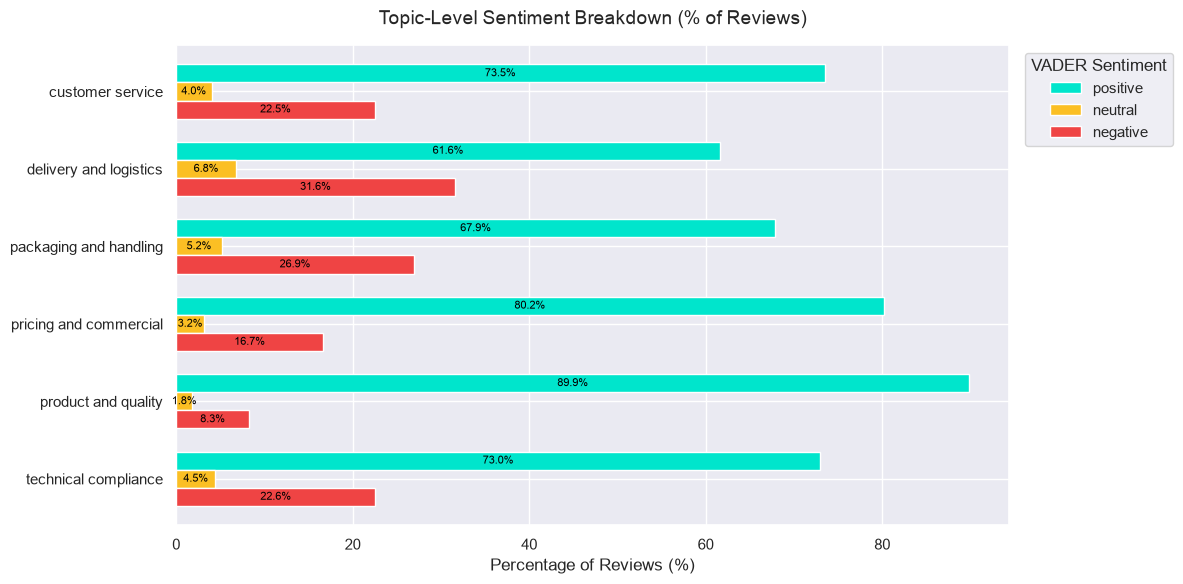

Saved: outputs/figures/topic_sentiment_breakdown.png

vader_label             positive  neutral  negative
topic_label                                        
customer service            73.5      4.0      22.5
delivery and logistics      61.6      6.8      31.6
packaging and handling      67.9      5.2      26.9
pricing and commercial      80.2      3.2      16.7
product and quality         89.9      1.8       8.3
technical compliance        73.0      4.5      22.6


In [17]:
# Cross-tabulate topic vs VADER sentiment (proportions)
topic_sentiment = pd.crosstab(
    df_analysis['topic_label'],
    df_analysis['vader_label'],
    normalize='index'
) * 100

# Reorder columns for visual consistency
col_order = [c for c in ['positive', 'neutral', 'negative'] if c in topic_sentiment.columns]
topic_sentiment = topic_sentiment[col_order]

colors = {'positive': '#00E5CC', 'neutral': '#FBBF24', 'negative': '#EF4444'}
bar_colors = [colors[c] for c in col_order]

ax = topic_sentiment.plot(
    kind='barh',
    figsize=(12, 6),
    color=bar_colors,
    width=0.7
)

ax.set_title('Topic-Level Sentiment Breakdown (% of Reviews)', fontsize=14, pad=15)
ax.set_xlabel('Percentage of Reviews (%)', fontsize=12)
ax.set_ylabel('')
ax.legend(title='VADER Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.invert_yaxis()
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8, color='black')

plt.tight_layout()
plt.savefig('../outputs/figures/topic_sentiment_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/topic_sentiment_breakdown.png')
print()
print(topic_sentiment.round(1).to_string())

### 3.3 Topic × Severity Rating Heatmap

Cross-tabulate each topic against the 5-point severity rating and display as a heatmap. Darker cells indicate higher complaint density. Average rating per topic highlights which area has the most severe complaints.

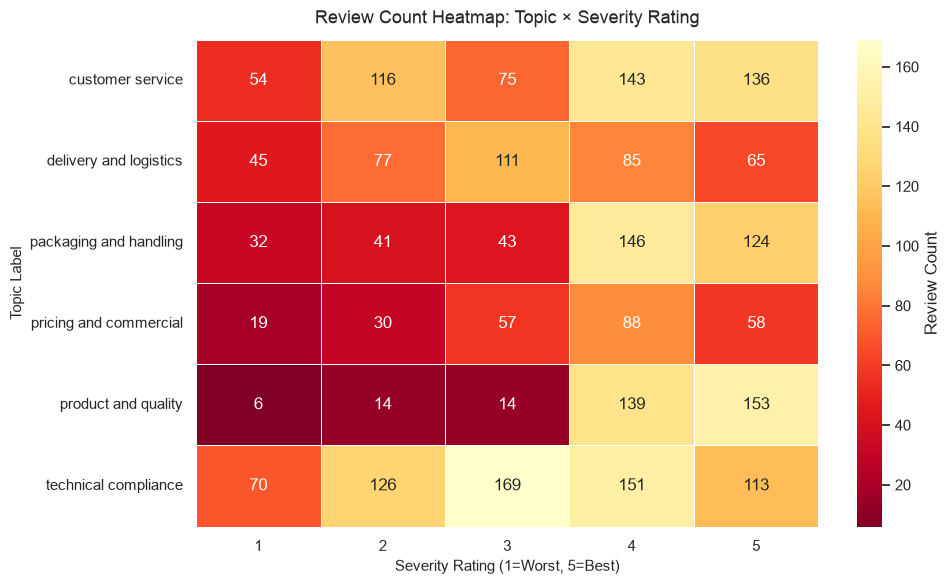

Saved: outputs/figures/topic_rating_heatmap.png


In [18]:
import seaborn as sns

# Cross-tab: average rating per topic (heatmap style)
rating_counts = pd.crosstab(df_analysis['topic_label'], df_analysis['rating'])

plt.figure(figsize=(10, 6))
sns.heatmap(
    rating_counts,
    cmap='YlOrRd_r',   # red = higher density → more complaints at low ratings
    annot=True,
    fmt='d',
    linewidths=0.5,
    cbar_kws={'label': 'Review Count'}
)
plt.title('Review Count Heatmap: Topic × Severity Rating', fontsize=13, pad=12)
plt.xlabel('Severity Rating (1=Worst, 5=Best)', fontsize=11)
plt.ylabel('Topic Label', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/figures/topic_rating_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/topic_rating_heatmap.png')

### 3.4 Topic Distribution by Customer Region

Cross-tabulate topics against customer regions to identify geographic complaint patterns. For instance, East India may generate more delivery & logistics complaints due to longer transit distances.

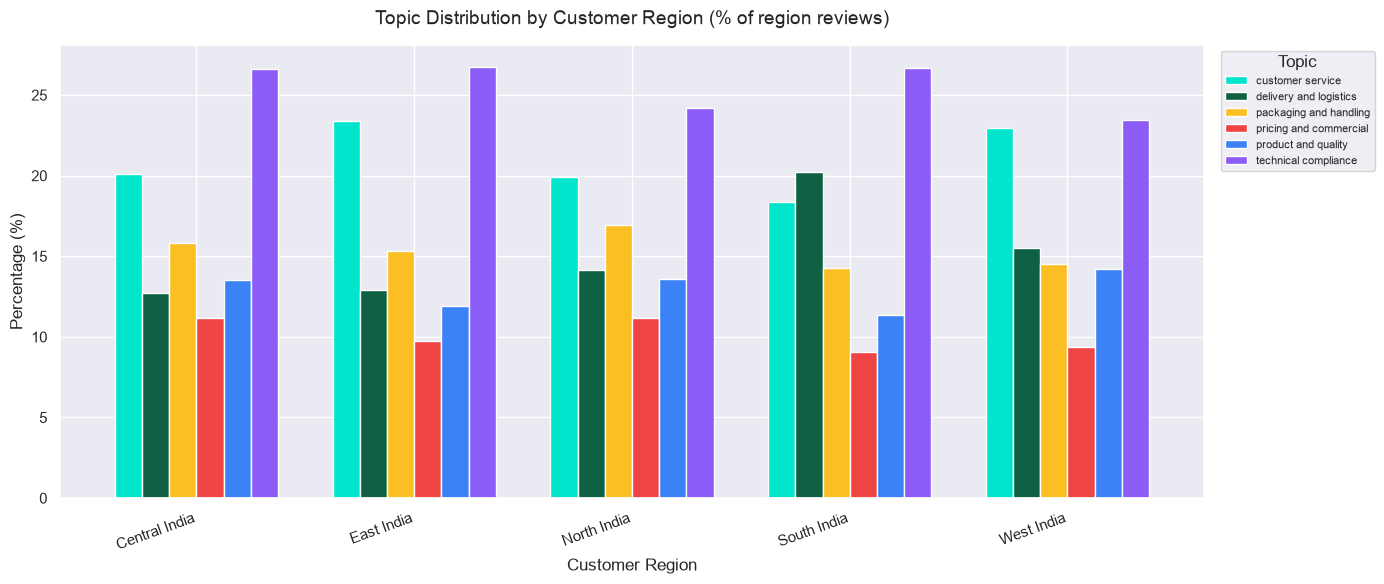

Saved: outputs/figures/topic_region_distribution.png

Top topic per region:
customer_region
Central India    technical compliance
East India       technical compliance
North India      technical compliance
South India      technical compliance
West India       technical compliance


In [19]:
region_topic = pd.crosstab(
    df_analysis['customer_region'],
    df_analysis['topic_label'],
    normalize='index'
) * 100

topic_colors = [
    '#00E5CC', '#0E6243', '#FBBF24', '#EF4444', '#3B82F6', '#8B5CF6'
]

ax = region_topic.plot(
    kind='bar',
    figsize=(14, 6),
    color=topic_colors[:len(region_topic.columns)],
    width=0.75
)

ax.set_title('Topic Distribution by Customer Region (% of region reviews)', fontsize=14, pad=15)
ax.set_xlabel('Customer Region', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Topic', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/figures/topic_region_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/topic_region_distribution.png')
print()
print('Top topic per region:')
print(region_topic.idxmax(axis=1).to_string())

### 3.5 Topic Distribution by Product Category

Identify which product lines generate which types of complaints. HR Plates and Coils may dominate product & quality issues while TMT Rebars could skew toward pricing or delivery topics.

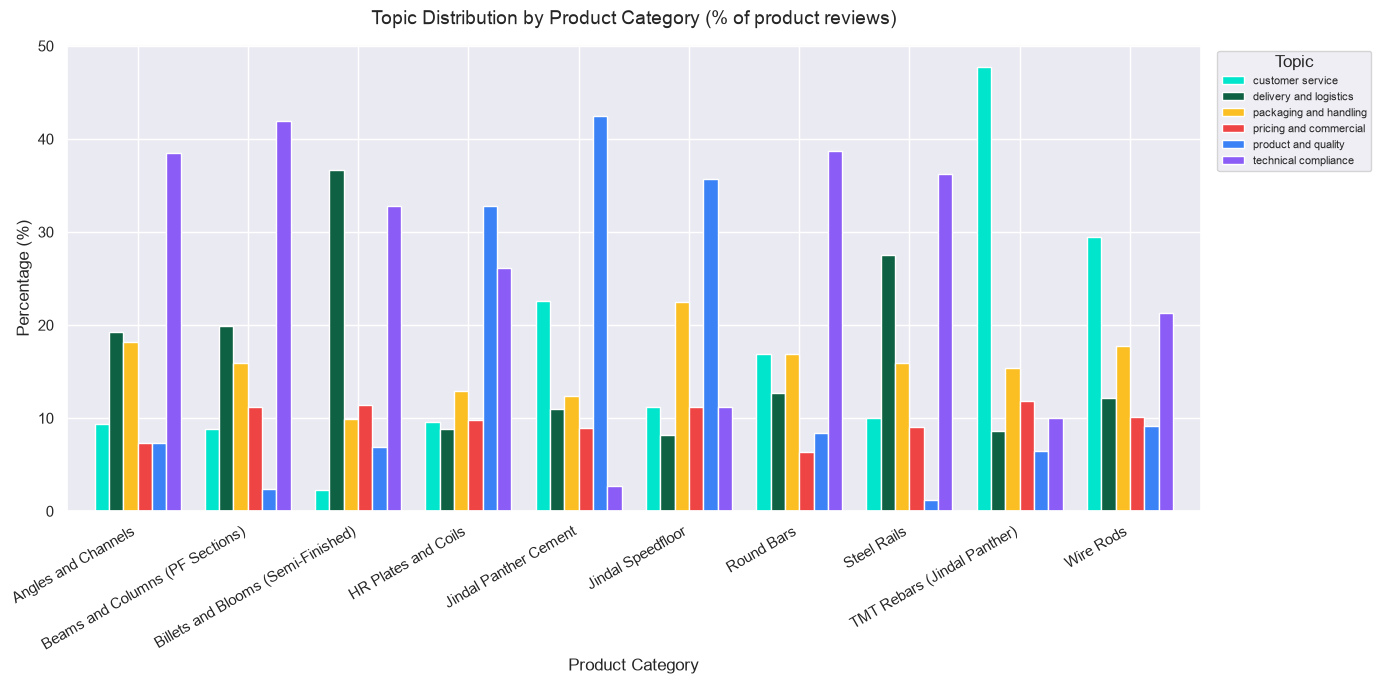

Saved: outputs/figures/topic_product_distribution.png

Top topic per product:
product_category
Angles and Channels                     technical compliance
Beams and Columns (PF Sections)         technical compliance
Billets and Blooms (Semi-Finished)    delivery and logistics
HR Plates and Coils                      product and quality
Jindal Panther Cement                    product and quality
Jindal Speedfloor                        product and quality
Round Bars                              technical compliance
Steel Rails                             technical compliance
TMT Rebars (Jindal Panther)                 customer service
Wire Rods                                   customer service


In [20]:
product_topic = pd.crosstab(
    df_analysis['product_category'],
    df_analysis['topic_label'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(14, 7))

product_topic.plot(
    kind='bar',
    ax=ax,
    color=topic_colors[:len(product_topic.columns)],
    width=0.78
)

ax.set_title('Topic Distribution by Product Category (% of product reviews)', fontsize=14, pad=15)
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Topic', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/figures/topic_product_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/topic_product_distribution.png')
print()
print('Top topic per product:')
print(product_topic.idxmax(axis=1).to_string())

### Week 3 Topic & Entity Insights

- **Technical Compliance Dominance**: Across all regions, `technical compliance` stands out as the most dominant topic (often linked to standard specifications like IS 2062 or IS 1786). This highlights that B2B steel customers prioritize strict adherence to manufacturing standards and certification documentation.
- **High-Friction Areas**: Topics like `customer service` and `pricing and commercial` skew towards lower average severity ratings, identifying customer touchpoints and billing coordination as critical operational bottlenecks.
- **Product-Level Skews**: Flat products (like *HR Plates and Coils*) and construction items (*Panther Cement*, *Speedfloor*) drive the highest volume of `product and quality` feedback, whereas long products like *TMT Rebars* skew towards delivery coordination and customer service.
- **High-Signal Named Entities**: Integrating spaCy's NER with B2B quality keywords successfully extracts high-signal tags like specific plant locations (*Angul, Raigarh*), standards (*IS 2062, IS 1786*), and industrial terms (*pitting, degraded, tensile*), bridging unstructured text and structured dashboard filtering.

## Week 3 Summary

### Key Findings & Analytical Value
1. **Unsupervised Categorisation**: Successfully grouped 10,000 feedback reviews into 6 business-defined topics (`product and quality`, `delivery and logistics`, `technical compliance`, `customer service`, `packaging and handling`, `pricing and commercial`) with an unsupervised Gensim LDA model (6 topics, 10 passes).
2. **Granular Cross-Tabulations**: Cross-referencing topics against ground-truth ratings, region, and product categories reveals geographic and product-specific friction points that global metrics miss.
3. **Entity and Keyword Fusion**: Built a lightweight extraction pipeline that combines statistical NER (spaCy) with domain-specific keyword mapping to power live, high-precision tagging in the Streamlit application.